In [1]:
import nibabel as nib
import matplotlib.pyplot as plt

/Users/rumethsandinu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Text(0.5, 1.0, 'Mask')

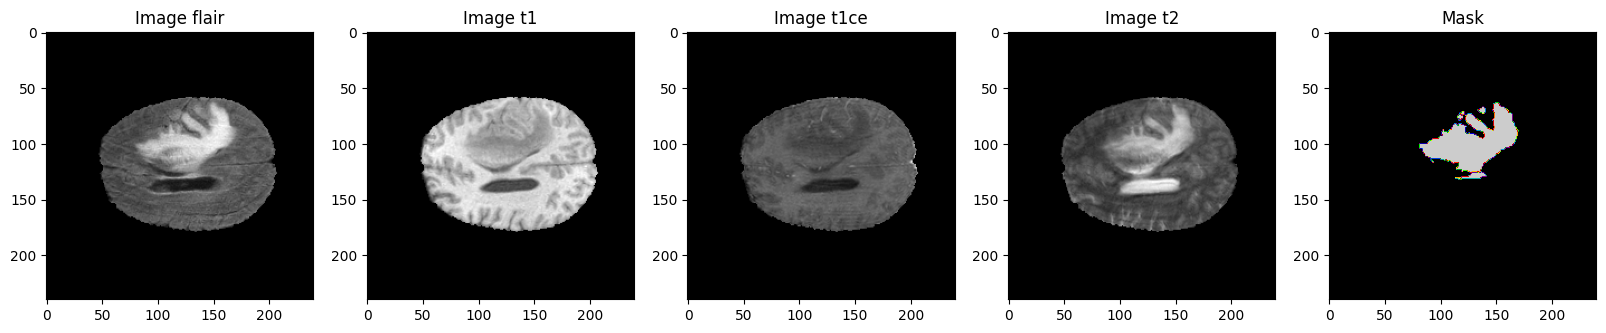

In [2]:
TRAIN_DATASET_PATH = '../../BraTS20/'

test_image_flair=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize = (20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:,:,test_image_flair.shape[0]//2-slice_w], cmap = 'gray')
ax1.set_title('Image flair')
ax2.imshow(test_image_t1[:,:,test_image_t1.shape[0]//2-slice_w], cmap = 'gray')
ax2.set_title('Image t1')
ax3.imshow(test_image_t1ce[:,:,test_image_t1ce.shape[0]//2-slice_w], cmap = 'gray')
ax3.set_title('Image t1ce')
ax4.imshow(test_image_t2[:,:,test_image_t2.shape[0]//2-slice_w], cmap = 'gray')
ax4.set_title('Image t2')

# ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w])
ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w], cmap='nipy_spectral')

ax5.set_title('Mask')

In [3]:
import cv2
import numpy as np

In [4]:
# pick slice with maximum tumor area
mask_area_per_slice = test_mask.sum(axis=(0, 1))
if np.any(mask_area_per_slice > 0):
    slice_idx = int(np.argmax(mask_area_per_slice))
else:
    slice_idx = int(test_image_t2.shape[2] // 2)

# extract slice and binarize mask (>0)
img = test_image_flair[:, :, slice_idx].astype(np.float32)
mask_slice = (test_mask[:, :, slice_idx] > 0).astype(np.uint8) * 255

# mormalize image to 0-255 uint8 for OpenCV
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
height, width = img.shape
print(f"Sample slice {slice_idx} loaded: shape {img.shape}, tumor pixels: {int(mask_slice.sum()//255)}")

Sample slice 68 loaded: shape (240, 240), tumor pixels: 5040


### Anisotropic Diffusion Filter

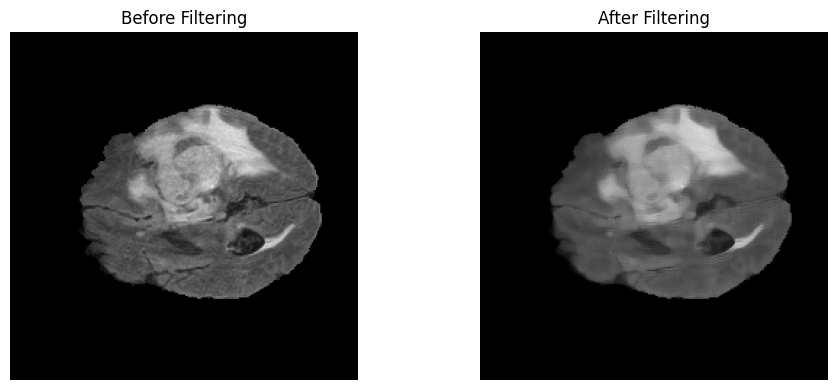

In [5]:
# anisotropic diffusion filter

def _grad_xy(u):

    # horizontal gradients
    gx = np.zeros_like(u, dtype=np.float32)

    # vertical gradients
    gy = np.zeros_like(u, dtype=np.float32)

    # approximate gradients using two neighours
    gx[:, 1:-1] = 0.5 * (u[:, 2:] - u[:, :-2])

    # approximate gradients for the right boundary
    gx[:, 0] = u[:, 1] - u[:, 0]

    # approximate gradients for the left boundary
    gx[:, -1] = u[:, -1] - u[:, -2]

    # verticl gradient approximation
    gy[1:-1, :] = 0.5 * (u[2:, :] - u[:-2, :])
    gy[0, :] = u[1, :] - u[0, :]
    gy[-1, :] = u[-1, :] - u[-2, :]
    return gx, gy


def _div(nx, ny):

    # horizontal divergence
    dx = np.zeros_like(nx, dtype=np.float32)

    # vertical divergence
    dy = np.zeros_like(ny, dtype=np.float32)

    # approximate gradients with backword difference
    dx[:, 1:-1] = nx[:, 1:-1] - nx[:, 0:-2]

    # set gradient 0 for left boundary
    dx[:, 0] = 0.0

    # right most column backword difference
    dx[:, -1] = nx[:, -1] - nx[:, -2]

    # vertical gradient calculation
    dy[1:-1, :] = ny[1:-1, :] - ny[0:-2, :]
    dy[0, :] = 0.0
    dy[-1, :] = ny[-1, :] - ny[-2, :]

    # return scaler field with some of the gradients
    return dx + dy


def anisotropic_diffusion(
    img,
    num_iter=15,

    # control sensitiviy to gradients
    k=25.0,

    # time-step scaling factor
    gamma=0.1,

    # gaussian pre-smoothing for g(|∇(Gσ*u)|)
    sigma=1.0
):
    """
    Implements anisotropic diffusion:
    - model='alvarez': ∂u/∂t = g(|∇(Gσ*u)|) * |∇u| * div(∇u/|∇u|)
      (Selective smoothing via mean-curvature motion with edge-stopping g)
    - model='pm': Perona–Malik with exponential/reciprocal conduction.
    Zero-flux (Neumann) boundary conditions.
    """
    u = img.astype(np.float32)
    gamma = float(min(gamma, 0.25))
    eps = 1e-6

    
    def g_func(s):
        return np.exp(- (s / k) ** 2)

    for _ in range(num_iter):

        # pre-smooth for robust edge detection in g(|∇(Gσ*u)|)
        u_blur = cv2.GaussianBlur(u, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
        gx_b, gy_b = _grad_xy(u_blur)
        mag_b = np.sqrt(gx_b * gx_b + gy_b * gy_b) + eps
        g = g_func(mag_b)

        # geometric terms on the current image u
        gx, gy = _grad_xy(u)
        mag = np.sqrt(gx * gx + gy * gy) + eps
        nx = gx / mag
        ny = gy / mag
        curvature = _div(nx, ny)

        u += gamma * (g * mag * curvature)
        
    return np.clip(u, 0, 255).astype(np.uint8)

# apply the filter to sample image
img_before = img.copy()
img = anisotropic_diffusion(img, num_iter=20, k=25, gamma=0.1, sigma=1.0)
img_after = img

# plot results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_before.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('Before Filtering')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_after.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('After Filtering')
plt.axis('off')
plt.tight_layout()
plt.show()

### Threshold to find bright seed points

In [6]:
ret, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
indexes = [(j, i) for j in range(height) for i in range(width) if th[j, i] == 255]

# choose the brightest pixel as seed for better tumor detection
seed_intensities = [img[j, i] for (j, i) in indexes]

# pixel with max intensity
seed = indexes[np.argmax(seed_intensities)]
print('Seed point:', seed)

Seed point: (106, 139)


### Region Growing Function
- Initialize a seed point
- Neighbour pixels with similar characteristics which satisfy the growth criteria would be merged
- This searching and merging process will be iterated until there are no pixels to merge


In [7]:
def region_growing(img, seed, region_threshold=41, max_pixels=None):
    """
    Args:
        img: Grayscale input image (uint8 or float)
        seed: Seed point as (y, x) cordinates
        region_threshold: Maximum allowed difference from region mean
        max_pixels: limit on region size
    
    Returns:
        Binary segmentation mask
    """

    # 4-connected neighborhood
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    height, width = img.shape
    
    # default max pixels to 50% of image
    if max_pixels is None:
        max_pixels = (height * width) // 2
    
    segmented_img = np.zeros((height, width), dtype=np.uint8)
    visited = np.zeros((height, width), dtype=bool)
    
    # initialize with seed point
    y, x = seed
    if not (0 <= y < height and 0 <= x < width):
        return segmented_img
    
    region_mean = float(img[y, x])
    region_size = 1
    segmented_img[y, x] = 255
    visited[y, x] = True
    
    # BFS to merge pixels
    queue = [(y, x)]
    
    while queue and region_size < max_pixels:
        cy, cx = queue.pop(0)
        
        for dy, dx in neighbors:
            ny, nx = cy + dy, cx + dx
            
            # boundary check
            if not (0 <= ny < height and 0 <= nx < width):
                continue
            
            if visited[ny, nx]:
                continue
            
            visited[ny, nx] = True
            
            # check intensity similarity criterion
            pixel_val = float(img[ny, nx])
            intensity_diff = abs(pixel_val - region_mean)
            
            if intensity_diff <= region_threshold:

                # add to region
                segmented_img[ny, nx] = 255
                queue.append((ny, nx))
                
                # update running mean
                region_size += 1
                region_mean = region_mean + (pixel_val - region_mean) / region_size
    
    return segmented_img

### Segment and Highlight Tumor

In [8]:
segmented_img = region_growing(img, seed, region_threshold=47)
highlighted = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
highlighted[segmented_img == 255] = [0, 0, 255]

### Display Results

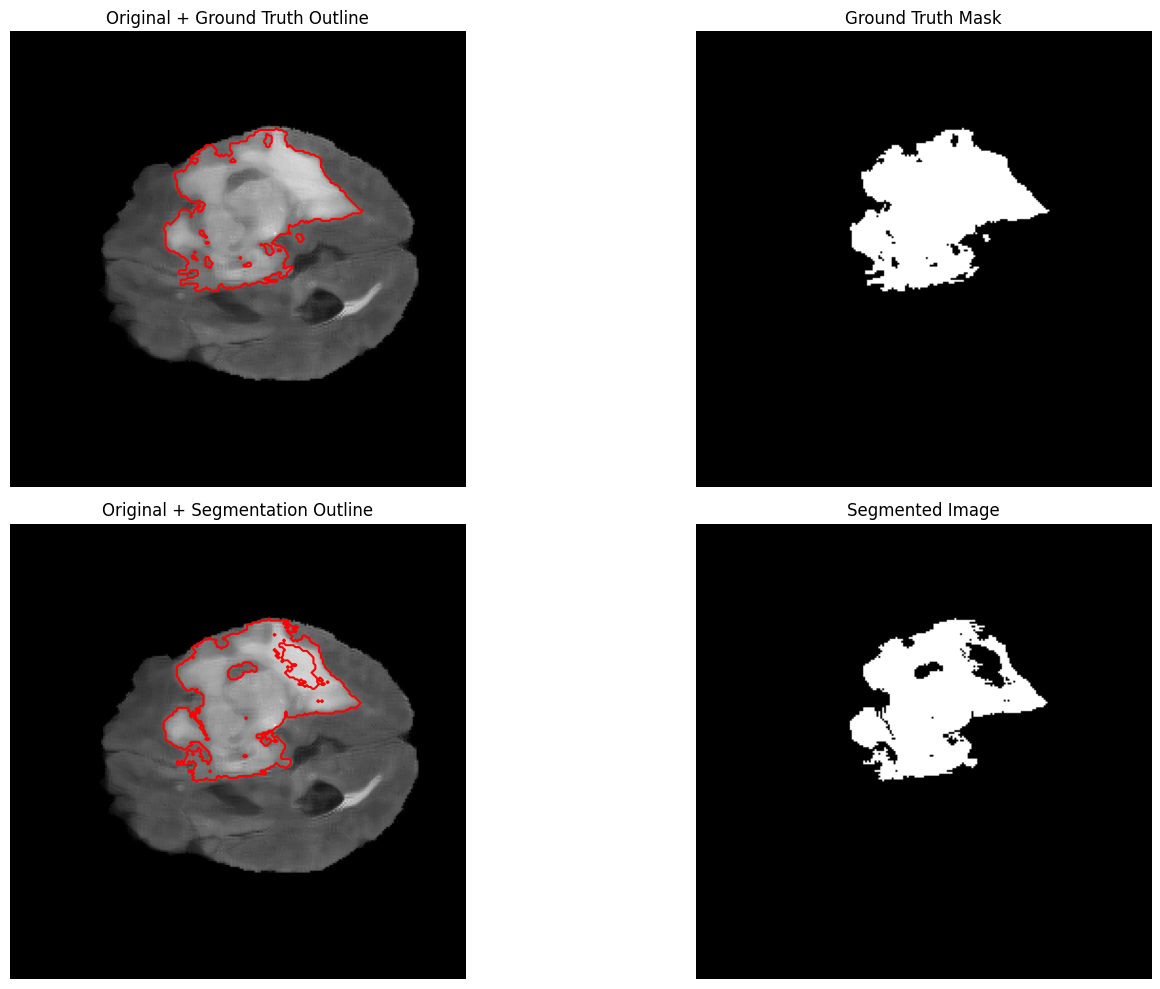

In [9]:
# plot results

img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
segmented_display = cv2.cvtColor(segmented_img, cv2.COLOR_GRAY2RGB)

# ground truth mask to RGB
gt_display = cv2.cvtColor(mask_slice, cv2.COLOR_GRAY2RGB)

# binary masks for contours
gt_bin = (mask_slice > 0).astype(np.uint8)
seg_bin = (segmented_img > 0).astype(np.uint8)

plt.figure(figsize=(16, 10))

# Original + Groud Truth Outline
plt.subplot(2, 2, 1)
plt.imshow(img_display)
plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Ground Truth Outline')
plt.axis('off')

# Ground Truth Mask
plt.subplot(2, 2, 2)
plt.imshow(gt_display)
plt.title('Ground Truth Mask')
plt.axis('off')

# Original + Segmentation outline
plt.subplot(2, 2, 3)
plt.imshow(img_display)
plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Segmentation Outline')
plt.axis('off')

# Segmented Image
plt.subplot(2, 2, 4)
plt.imshow(segmented_display)
plt.title('Segmented Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### Adaptive Region Growing Model

**Objective Function**:
   $$h = \alpha G_s + \beta \sigma_s^2$$
   
   Where:
   - $G_s = \frac{1}{\bar{g}_s}$ : Reciprocal of mean gradient along boundary (smoothness term)
   - $\sigma_s^2$ : Variance inside the segmented region (homogeneity term)
   - $\alpha, \beta$ : Weight coefficients

**Weight Coefficients**:
   
   Derived from circular ROI model with radius $r$, normal distribution inside (mean=1, std=$\delta$):
   - Mean gradient around circle: $\frac{1}{2\pi r}$
   - Mean variance: $\frac{\delta^2}{\pi r}$
   
   Constraint: $\alpha + \beta = 1$, ratio $\alpha : \beta = \frac{\delta}{2\pi} : \frac{1}{\pi} = \delta : 2$
   
   **Solution:** $\alpha = \frac{\delta}{\delta + 2}$, $\beta = \frac{2}{\delta + 2}$
   
   For $\delta = 10$: $\alpha \approx 0.833$, $\beta \approx 0.167$

**Algorithm Steps:**
   - a) Apply anisotropic filter on input image
   - b) Set seed point, initial threshold $T_0$ from 5×5 neighborhood
   - c) Get contour through region growing, calculate $h_0$
   - d) Iterate thresholds, calculate $h$ for each
   - e) Find minimum $h$ as optimal threshold

In [ ]:
def compute_weight_coefficients(delta=10.0):

    alpha = delta / (delta + 2.0)
    beta = 2.0 / (delta + 2.0)
    return alpha, beta


def get_initial_threshold(img, seed, neighborhood_size=5):
    y, x = seed
    h, w = img.shape
    half = neighborhood_size // 2
    
    # cxtract neighborhood with boundary handling
    y_min = max(0, y - half)
    y_max = min(h, y + half + 1)
    x_min = max(0, x - half)
    x_max = min(w, x + half + 1)
    
    neighborhood = img[y_min:y_max, x_min:x_max]
    mean_val = np.mean(neighborhood)
    seed_val = float(img[y, x])
    
    # absolute difference
    T0 = abs(seed_val - mean_val)
    return max(T0, 5.0)


def select_seed_point(img):

    height, width = img.shape

    # find brightest pixel
    _, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    bright_pixels = [(j, i) for j in range(height) for i in range(width) if th[j, i] == 255]
    
    if bright_pixels:
        intensities = [img[j, i] for (j, i) in bright_pixels]
        seed = bright_pixels[np.argmax(intensities)]
    else:
        # fallback to global brightest
        flat_idx = np.argmax(img)
        seed = (flat_idx // width, flat_idx % width)

    return seed


def adaptive_region_growing(img, seed, delta=10.0, T_min=5, T_max=80, T_step=1):
    """
    Args:
        img: Input grayscale image (uint8)
        seed: Seed point (y, x)
        delta: Parameter for weight coefficient calculation
        T_min, T_max, T_step: Threshold search range
    
    Returns:
        dict with optimal segmentation, threshold, and diagnostic info
    """

    # coefficients
    alpha, beta = compute_weight_coefficients(delta)
    
    # gradient magnitude image using Sobel operator
    grad_x = cv2.Sobel(img.astype(np.float64), cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img.astype(np.float64), cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    T0 = get_initial_threshold(img, seed)
    
    # search range based on initial threshold
    T_start = max(T_min, int(T0 * 0.5))
    T_end = min(T_max, int(T0 * 3))
    
    results = []
    min_h = float('inf')
    optimal_threshold = None
    optimal_segmentation = None
    
    for T in range(T_start, T_end + 1, T_step):

        # run region growing with current threshold
        segmented_mask = region_growing(img, seed, region_threshold=T)
        
        # skip empty segmentations
        if np.sum(segmented_mask) == 0:
            continue
        
        # find boundary contour
        contours, _ = cv2.findContours(segmented_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            continue
        
        # create contour mask with 1px width
        contour_mask = np.zeros_like(segmented_mask)
        cv2.drawContours(contour_mask, contours, -1, 255, 1)
        
        # calculate variance inside the segmented region
        pixels_inside = img[segmented_mask == 255].astype(np.float64)
        if pixels_inside.size < 2:
            continue
        sigma_s_squared = np.var(pixels_inside)
        
        # calculate reciprocal of mean gradient along boundary
        gradient_on_boundary = gradient_magnitude[contour_mask == 255]
        if gradient_on_boundary.size == 0:
            continue
        
        mean_gradient = np.mean(gradient_on_boundary)
        if mean_gradient < 1e-6:
            continue
        G_s = 1.0 / mean_gradient
        
        # calculate objective function h
        h = (alpha * G_s) + (beta * sigma_s_squared)
        
        results.append({
            'T': T,
            'h': h,
            'G_s': G_s,
            'sigma_s_squared': sigma_s_squared,
            'mean_gradient': mean_gradient,
            'region_size': int(pixels_inside.size),
            'boundary_length': int(gradient_on_boundary.size)
        })
        
        # track minimum h
        if h < min_h:
            min_h = h
            optimal_threshold = T
            optimal_segmentation = segmented_mask.copy()
    
    
    
    # fallback if no valid segmentation found
    if optimal_segmentation is None:
        optimal_threshold = int(T0)
        optimal_segmentation = region_growing(img, seed, region_threshold=optimal_threshold)
    
    return {
        'segmentation': optimal_segmentation,
        'optimal_T': optimal_threshold,
        'min_h': min_h,
        'alpha': alpha,
        'beta': beta,
        'delta': delta,
        'initial_T0': T0,
        'results': results
    }


# select seed point
seed = select_seed_point(img)
print(f"Selected seed point: {seed} (intensity: {img[seed[0], seed[1]]})")

model_result = adaptive_region_growing(
    img, 
    seed, 
    delta=10.0,  # Paper uses δ=10
    T_min=5, 
    T_max=80, 
    T_step=1
)

print(f"delta = {model_result['delta']}")
print(f"alpha = {model_result['alpha']:.4f}")
print(f"beta  = {model_result['beta']:.4f}")
print(f"Initial T = {model_result['initial_T0']:.2f}")
print(f"Optimal: T = {model_result['optimal_T']} (min h = {model_result['min_h']:.6f})")

Selected seed point: (106, 139) (intensity: 243)
delta = 10.0
alpha = 0.8333
beta  = 0.1667
Initial T = 69.40
Optimal: T = 47 (min h = 97.568215)


In [11]:
# extract results from the model
segmented_image = model_result['segmentation']
optimal_threshold = model_result['optimal_T']
results = model_result['results']

# create highlighted visualization
highlighted = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
highlighted[segmented_image == 255] = [0, 0, 255]

print(f"Segmented region size: {np.sum(segmented_image > 0)} pixels")

Segmented region size: 4574 pixels


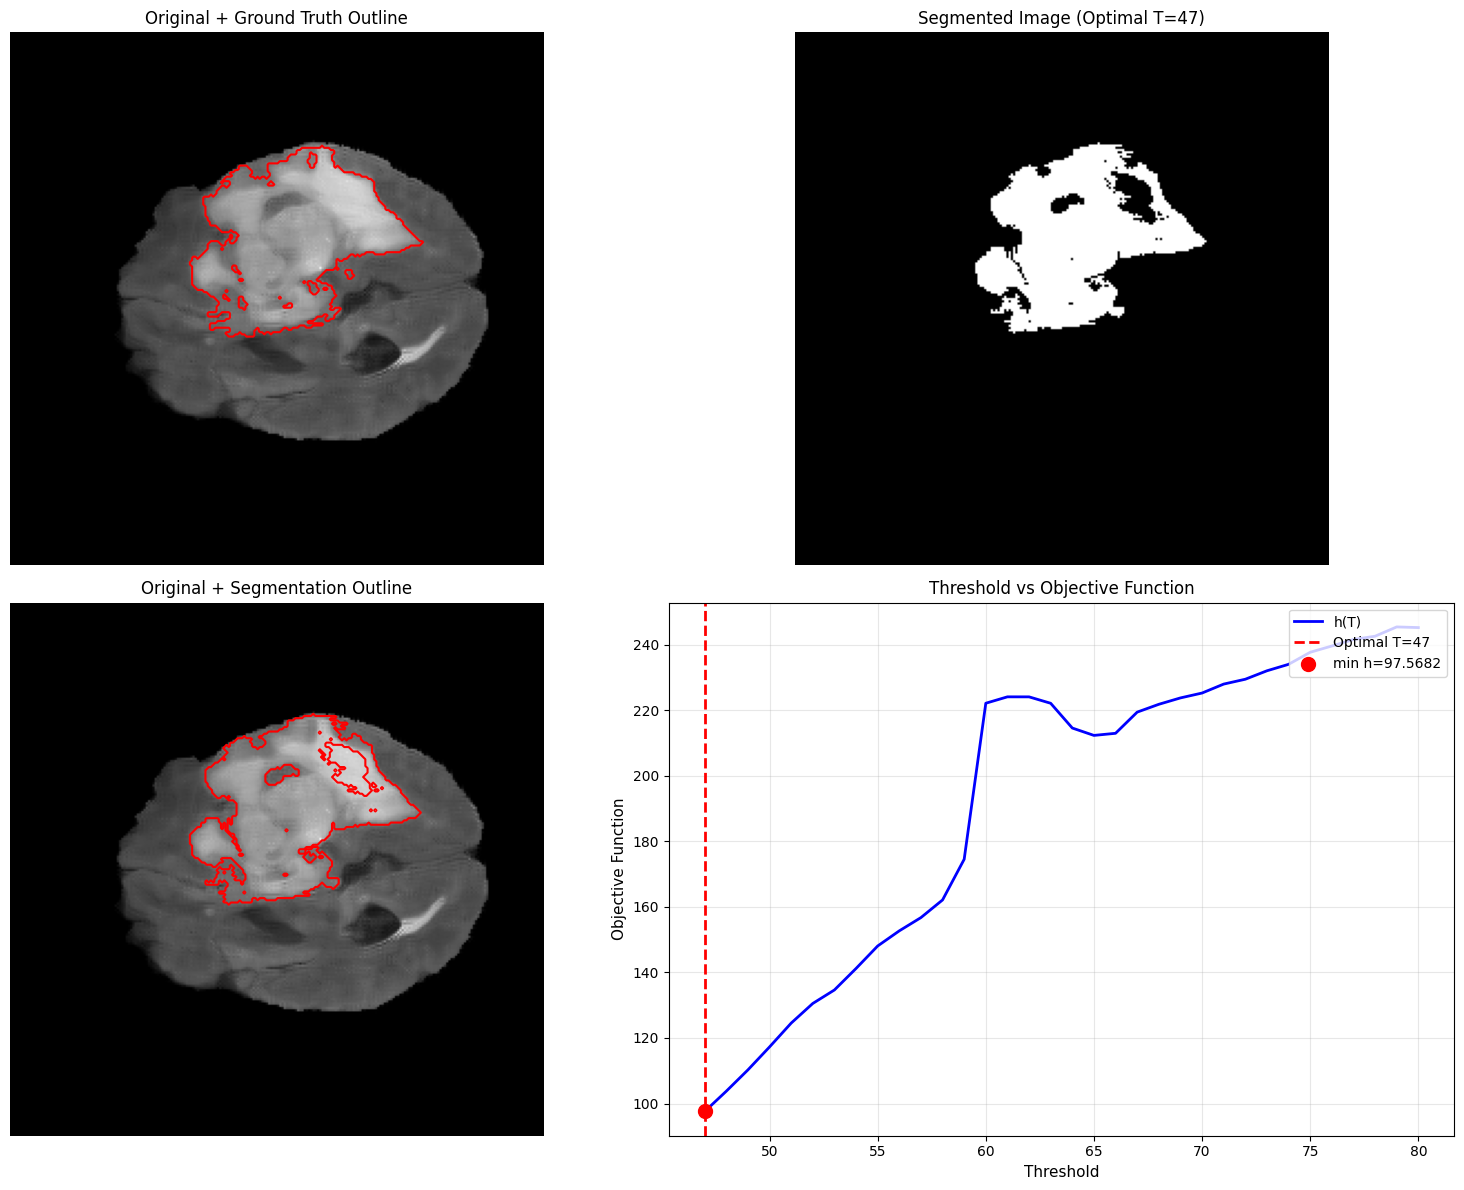

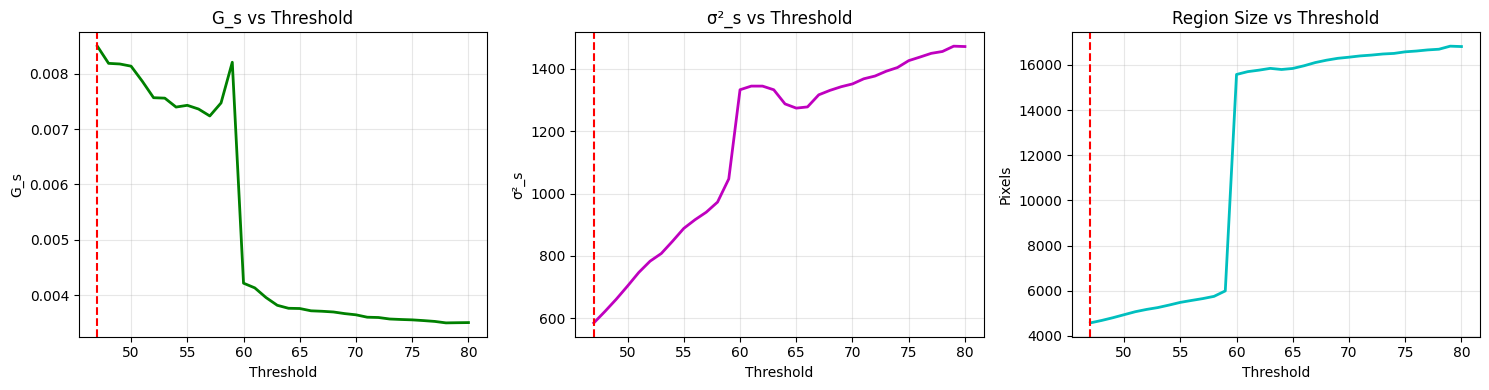

In [12]:
# color space conversion
img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
segmented_display = cv2.cvtColor(segmented_image, cv2.COLOR_GRAY2RGB)

gt_mask_bin = (mask_slice > 0).astype(np.uint8)
seg_mask_bin = (segmented_image > 0).astype(np.uint8)

fig = plt.figure(figsize=(16, 12))

# Original Image + Ground Truth Outline
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(img_display)
ax1.contour(gt_mask_bin, levels=[0.5], colors='red', linewidths=1.5)
ax1.set_title('Original + Ground Truth Outline', fontsize=12)
ax1.axis('off')

# Segmented Image
ax2 = fig.add_subplot(2, 2, 2)
ax2.imshow(segmented_display)
ax2.set_title(f'Segmented Image (Optimal T={optimal_threshold})', fontsize=12)
ax2.axis('off')

# Original Image + Segmentation outline
ax3 = fig.add_subplot(2, 2, 3)
ax3.imshow(img_display)
ax3.contour(seg_mask_bin, levels=[0.5], colors='red', linewidths=1.5)
ax3.set_title('Original + Segmentation Outline', fontsize=12)
ax3.axis('off')

# Threshold vs. Objective Function
ax4 = fig.add_subplot(2, 2, 4)
if results:
    threshold_vals = [r['T'] for r in results]
    h_vals = [r['h'] for r in results]
    
    ax4.plot(threshold_vals, h_vals, 'b-', linewidth=2, label='h(T)')
    ax4.axvline(x=optimal_threshold, color='r', linestyle='--', linewidth=2, 
                label=f'Optimal T={optimal_threshold}')
    ax4.scatter([optimal_threshold], [model_result['min_h']], color='red', s=100, 
                zorder=5, label=f'min h={model_result["min_h"]:.4f}')
    
    ax4.set_title("Threshold vs Objective Function", fontsize=12)
    ax4.set_xlabel('Threshold', fontsize=11)
    ax4.set_ylabel('Objective Function', fontsize=11)
    ax4.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No results to plot', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()

if results:
    fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # G_s (boundary smoothness term)
    axes[0].plot(threshold_vals, [r['G_s'] for r in results], 'g-', linewidth=2)
    axes[0].axvline(x=optimal_threshold, color='r', linestyle='--')
    axes[0].set_title('G_s vs Threshold')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('G_s')
    axes[0].grid(True, alpha=0.3)
    
    # σ²_s (region homogeneity term)
    axes[1].plot(threshold_vals, [r['sigma_s_squared'] for r in results], 'm-', linewidth=2)
    axes[1].axvline(x=optimal_threshold, color='r', linestyle='--')
    axes[1].set_title('σ²_s vs Threshold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('σ²_s')
    axes[1].grid(True, alpha=0.3)
    
    # Region size
    axes[2].plot(threshold_vals, [r['region_size'] for r in results], 'c-', linewidth=2)
    axes[2].axvline(x=optimal_threshold, color='r', linestyle='--')
    axes[2].set_title('Region Size vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Pixels')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Apply the Filter and Segment the Samples

In [13]:
import glob
import os
from tqdm.auto import tqdm
from math import pi
import time

/Users/rumethsandinu/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
ALL_CASES_PATH = TRAIN_DATASET_PATH.rstrip("/") + "/"
use_modality = "flair"


def apply_anisotropic_filter_to_all(all_cases_path, modality, num_iter=20, k=25, gamma=0.1, sigma=1.0):
    """
    Args:
        all_cases_path: Path to BraTS dataset
        modality: MRI modality ('flair', 't1', 't1ce', 't2')
        num_iter, k, gamma, sigma: Anisotropic diffusion parameters
    
    Returns:
        filtered_cases: List of filtered image data
        stats_list: List of statistics
    """
    case_dirs = sorted([d for d in glob.glob(os.path.join(all_cases_path, "BraTS20_Training_*")) 
                        if os.path.isdir(d)])
    if not case_dirs:
        raise FileNotFoundError(f"No case folders found in: {all_cases_path}")

    filtered = []
    stats_list = []
    pbar = tqdm(case_dirs, desc=f"Filtering ({modality})", unit="case")

    for case_dir in pbar:
        case_id = os.path.basename(case_dir)
        mod_glob = glob.glob(os.path.join(case_dir, f"{case_id}_{modality}.nii*"))
        seg_glob = glob.glob(os.path.join(case_dir, f"{case_id}_seg.nii*"))
        
        if not mod_glob or not seg_glob:
            continue
            
        mod_path = mod_glob[0]
        seg_path = seg_glob[0]

        try:
            vol = nib.load(mod_path).get_fdata().astype(np.float32)
            seg = nib.load(seg_path).get_fdata().astype(np.float32)
        except Exception as e:
            print(f"Failed to load {case_id}: {e}")
            continue

        # select slice with maximum tumor area
        areas = seg.sum(axis=(0, 1))
        if np.any(areas > 0):
            k_slice = int(np.argmax(areas))
        else:
            k_slice = vol.shape[2] // 2

        img_slice_f = vol[:, :, k_slice]
        mask_slice = (seg[:, :, k_slice] > 0).astype(np.uint8) * 255

        # normalize to 0-255 uint8
        img_u8 = cv2.normalize(img_slice_f, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # apply anisotropic diffusion filter
        t0 = time.perf_counter()
        img_filt = anisotropic_diffusion(
            img_u8,
            num_iter=num_iter,
            k=k,
            gamma=gamma,
            sigma=sigma
        )
        t1 = time.perf_counter()
        filt_dt = t1 - t0

        stats_list.append({
            "case": case_id,
            "slice": k_slice,
            "mean": float(img_filt.mean()),
            "std": float(img_filt.std())
        })

        filtered.append({
            "case": case_id,
            "slice": k_slice,
            "mod": modality,
            "img_orig": img_u8,
            "img_filt": img_filt,
            "mask_slice": mask_slice,
            "filter_time_s": float(filt_dt),
            "filter_num_iter": int(num_iter)
        })

    print(f'\nSuccessfully filtered {len(filtered)} cases with anisotropic diffusion')
    return filtered, stats_list


def segment_cases(filtered_cases, delta=10.0, T_min=5, T_max=80, T_step=1):
    """
    Args:
        filtered_cases: List of filtered image data from apply_anisotropic_filter_to_all
        delta: Weight coefficient parameter
        T_min, T_max, T_step: Threshold search range
    
    Returns:
        segmented_cases: List with segmentation results
    """
    segmented = []
    pbar = tqdm(filtered_cases, desc="Segmentation", unit="case")
    
    for item in pbar:
        img_filt = item["img_filt"]
        mask_slice = item["mask_slice"]
        
        # select seed point
        seed = select_seed_point(img_filt)
        
        # time
        t0 = time.perf_counter()
        
        # adaptive model
        model_result = adaptive_region_growing(
            img_filt, 
            seed, 
            delta=delta,
            T_min=T_min, 
            T_max=T_max, 
            T_step=T_step
        )
        
        t1 = time.perf_counter()
        seg_dt = t1 - t0
        
        segmented.append({
            **item,
            "seed": seed,
            "best_T": model_result['optimal_T'],
            "best_mask": model_result['segmentation'],
            "min_h": model_result['min_h'],
            "alpha": model_result['alpha'],
            "beta": model_result['beta'],
            "initial_T0": model_result['initial_T0'],
            "segment_time_s": float(seg_dt),
            "tested_Ts": len(model_result['results'])
        })
    
    print(f'\nSuccessfully segmented {len(segmented)} cases')
    return segmented

## Flair

In [15]:
filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases)

Filtering (flair): 100%|██████████| 369/369 [00:29<00:00, 12.72case/s]



Successfully filtered 368 cases with anisotropic diffusion


Segmentation: 100%|██████████| 368/368 [01:51<00:00,  3.30case/s]


Successfully segmented 368 cases


In [16]:
# mean inference time

filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, segmentation: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 271.22 ms
filter: 9.27 ms, segmentation: 261.95 ms


### Results

In [17]:
import pandas as pd

Training slice count: 368


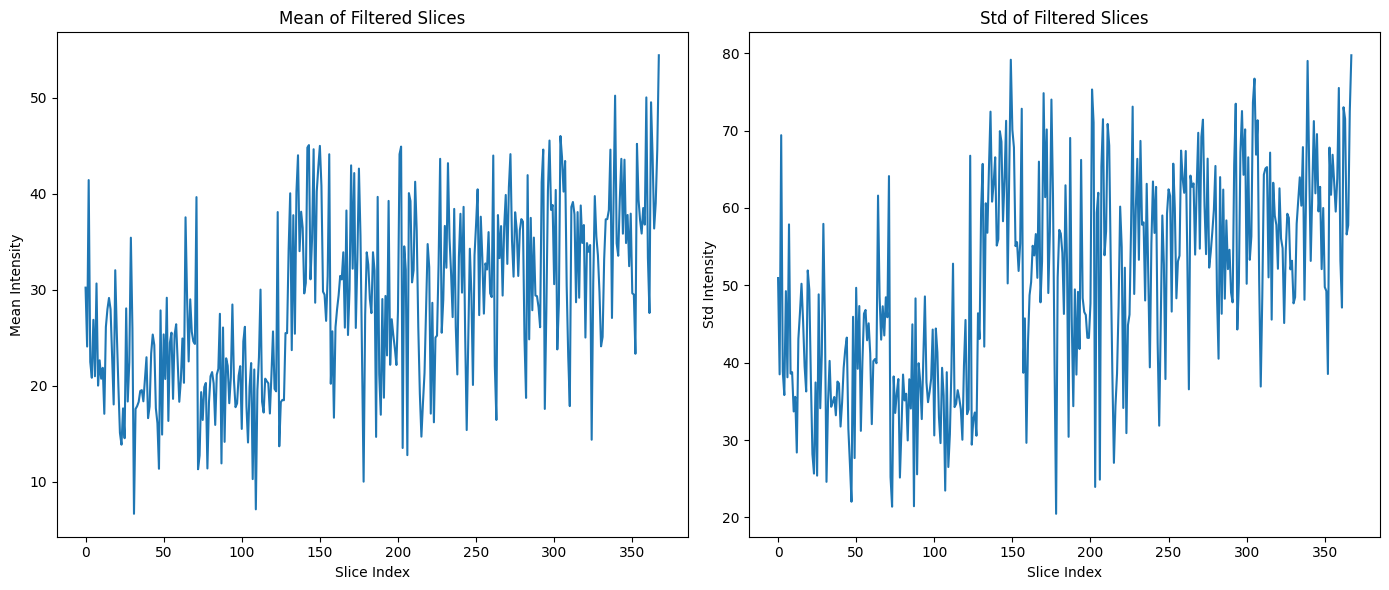

In [18]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

### Evaluation Pipeline

In [19]:
from scipy.ndimage import binary_erosion, distance_transform_edt

In [20]:
def dice_coefficient(y_true, y_pred, eps=1e-7):
    """
    Args:
        y_true, y_pred: Binary masks (0/1)
        eps: Small constant for numerical stability
    
    Returns:
        Dice coefficient in range [0, 1]
    """
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    
    intersection = np.logical_and(y_true, y_pred).sum()
    return (2.0 * intersection + eps) / (y_true.sum() + y_pred.sum() + eps)


def jaccard_index_iou(y_true, y_pred, eps=1e-7):
    """
    
    Args:
        y_true, y_pred: Binary masks (0/1)
        eps: Small constant for numerical stability
    
    Returns:
        Jaccard index in range [0, 1]
    """
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return (intersection + eps) / (union + eps)


def normalized_surface_dice(pred, gt, tolerance=2):
    """
    Args:
        pred, gt: Binary masks (0/1 or False/True)
        tolerance: Distance threshold in pixels
    
    Returns:
        NSD score in range [0, 1]
    """
    pred = np.asarray(pred).astype(bool)
    gt = np.asarray(gt).astype(bool)

    # handle empty cases
    if pred.sum() == 0 and gt.sum() == 0:
        return 1.0
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    struct = np.ones((3, 3), dtype=bool)

    # extract 1-pixel wide boundary of each mask
    pred_surface = np.logical_xor(pred, binary_erosion(pred, structure=struct, border_value=0))
    gt_surface = np.logical_xor(gt, binary_erosion(gt, structure=struct, border_value=0))

    if pred_surface.sum() == 0 or gt_surface.sum() == 0:
        return 0.0

    # distance transform from ground truth surface
    dist_from_gt = distance_transform_edt(~gt_surface)
    dist_from_pred = distance_transform_edt(~pred_surface)

    pred_to_gt = dist_from_gt[pred_surface]
    gt_to_pred = dist_from_pred[gt_surface]
    
    if pred_to_gt.size == 0 or gt_to_pred.size == 0:
        return 0.0

    nsd_pred_to_gt = np.mean(pred_to_gt <= tolerance)
    nsd_gt_to_pred = np.mean(gt_to_pred <= tolerance)
    
    return float((nsd_pred_to_gt + nsd_gt_to_pred) / 2.0)

In [21]:
def evaluate_segmentation_results(segmented_cases, modality):
    """
    
    Args:
        segmented_cases: List of segmentation results
        modality: Name of modality for display
    
    Returns:
        DataFrame with evaluation results
    """
    if not segmented_cases:
        print("No segmented cases found.")
        return pd.DataFrame()
    
    eval_results = []
    count_considered = 0
    count_skipped = 0

    for sample in segmented_cases:
        gt_mask = (sample["mask_slice"] > 0).astype(np.uint8)
        pred_mask = (sample["best_mask"] > 0).astype(np.uint8)

        # skip slices with empty mask
        if gt_mask.sum() == 0:
            count_skipped += 1
            continue

        count_considered += 1

        # calculate metrics
        dsc = dice_coefficient(gt_mask, pred_mask)
        iou = jaccard_index_iou(gt_mask, pred_mask)
        nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

        eval_results.append({
            "case": sample["case"],
            "slice": sample["slice"],
            "best_T": sample.get("best_T", None),
            "dice": dsc,
            "iou": iou,
            "nsd": nsd,
        })

    results_df = pd.DataFrame(eval_results)

    print(f"Evaluation Results {f'({modality})' if modality else ''}")
    print(f"Samples evaluated: {count_considered}")
    print(f"Samples with empty mask: {count_skipped}")
    
    if count_considered > 0:
        print(results_df[["dice", "iou", "nsd"]].describe())
    return results_df


# evaluation
results_df2 = evaluate_segmentation_results(segmented_cases, modality=use_modality)

Evaluation Results (flair)
Samples evaluated: 368
Samples with empty mask: 0
               dice           iou         nsd
count  3.680000e+02  3.680000e+02  368.000000
mean   1.897045e-01  1.351973e-01    0.152532
std    2.546345e-01  2.195199e-01    0.224408
min    1.634254e-11  1.634254e-11    0.000000
25%    2.069996e-02  1.045823e-02    0.000000
50%    8.493520e-02  4.435112e-02    0.008284
75%    2.174598e-01  1.219946e-01    0.266331
max    9.630096e-01  9.286582e-01    0.948561


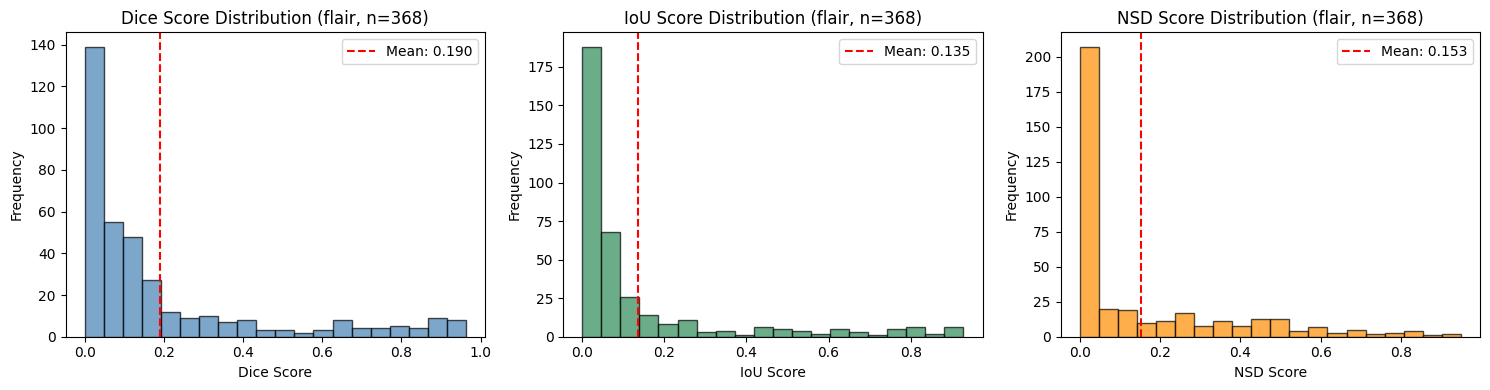

In [22]:
def plot_evaluation_histograms(results_df, modality):
    if results_df is None or results_df.empty:
        print("No evaluation results to plot.")
        return
    
    n = len(results_df)
    title_suffix = f" ({modality}, n={n})" if modality else f" (n={n})"
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Dice Score
    axes[0].hist(results_df["dice"], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(results_df["dice"].mean(), color='red', linestyle='--', label=f'Mean: {results_df["dice"].mean():.3f}')
    axes[0].set_title(f"Dice Score Distribution{title_suffix}")
    axes[0].set_xlabel("Dice Score")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    
    # IoU
    axes[1].hist(results_df["iou"], bins=20, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(results_df["iou"].mean(), color='red', linestyle='--', label=f'Mean: {results_df["iou"].mean():.3f}')
    axes[1].set_title(f"IoU Score Distribution{title_suffix}")
    axes[1].set_xlabel("IoU Score")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    
    # NSD
    axes[2].hist(results_df["nsd"], bins=20, color='darkorange', edgecolor='black', alpha=0.7)
    axes[2].axvline(results_df["nsd"].mean(), color='red', linestyle='--', label=f'Mean: {results_df["nsd"].mean():.3f}')
    axes[2].set_title(f"NSD Score Distribution{title_suffix}")
    axes[2].set_xlabel("NSD Score")
    axes[2].set_ylabel("Frequency")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# plot mteric distributions
plot_evaluation_histograms(results_df2, modality=use_modality)

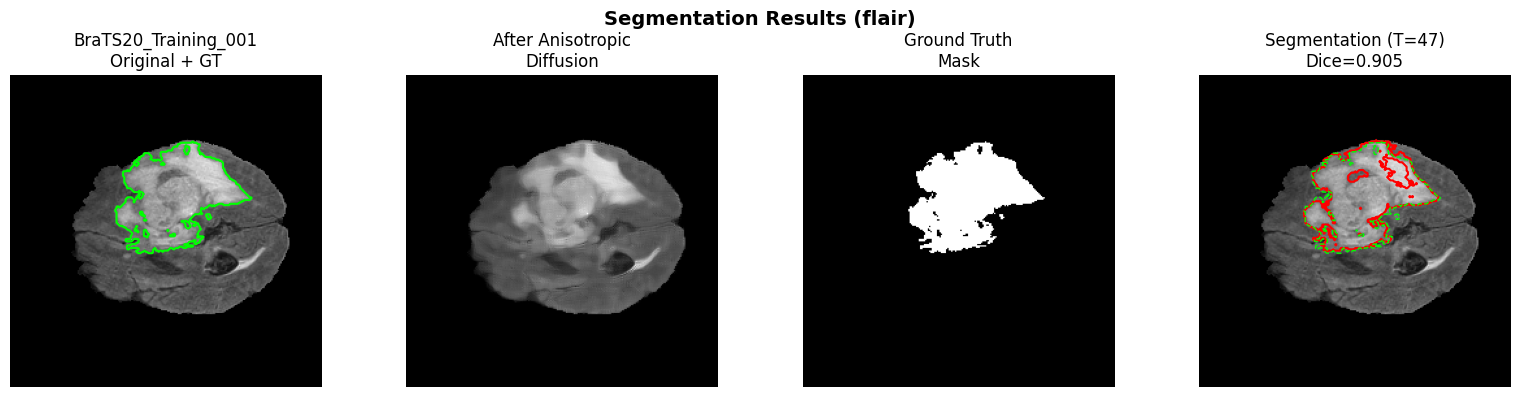

In [23]:
def visualize_first_sample(segmented_cases, modality):
    """
    Args:
        segmented_cases: List of segmentation results
        modality: Name of the modality for display
    """
    if not segmented_cases:
        print("No segmented cases to visualize.")
        return
    
    sample = segmented_cases[0]
    img_orig = sample["img_orig"]
    img_filt = sample["img_filt"]
    gt_mask = sample["mask_slice"]
    best_mask = sample["best_mask"]
    best_T = sample.get("best_T", None)
    case_name = sample.get("case", "Sample 0")

    gt_bin = (gt_mask > 0).astype(np.uint8)
    seg_bin = (best_mask > 0).astype(np.uint8)
    dice = dice_coefficient(gt_bin, seg_bin)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    axes[0].contour(gt_bin, levels=[0.5], colors='lime', linewidths=1.5)
    axes[0].set_title(f"{case_name}\nOriginal + GT")
    axes[0].axis('off')

    axes[1].imshow(img_filt, cmap='gray')
    axes[1].set_title("After Anisotropic\nDiffusion")
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(gt_mask, cv2.COLOR_GRAY2RGB))
    axes[2].set_title("Ground Truth\nMask")
    axes[2].axis('off')

    axes[3].imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    axes[3].contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
    axes[3].contour(gt_bin, levels=[0.5], colors='lime', linewidths=1, linestyles='--')
    axes[3].set_title(f"Segmentation (T={best_T})\nDice={dice:.3f}")
    axes[3].axis('off')

    fig.suptitle(f"Segmentation Results ({modality})", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_first_sample(segmented_cases, use_modality)

## T1

In [24]:
use_modality = 't1'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering (t1): 100%|██████████| 369/369 [00:28<00:00, 12.87case/s]



Successfully filtered 368 cases with anisotropic diffusion


Segmentation: 100%|██████████| 368/368 [01:58<00:00,  3.11case/s]


Successfully segmented 368 cases


In [25]:
# mean inference time

filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, segmentation: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 288.17 ms
filter: 9.20 ms, segmentation: 278.96 ms


Training slice count: 368


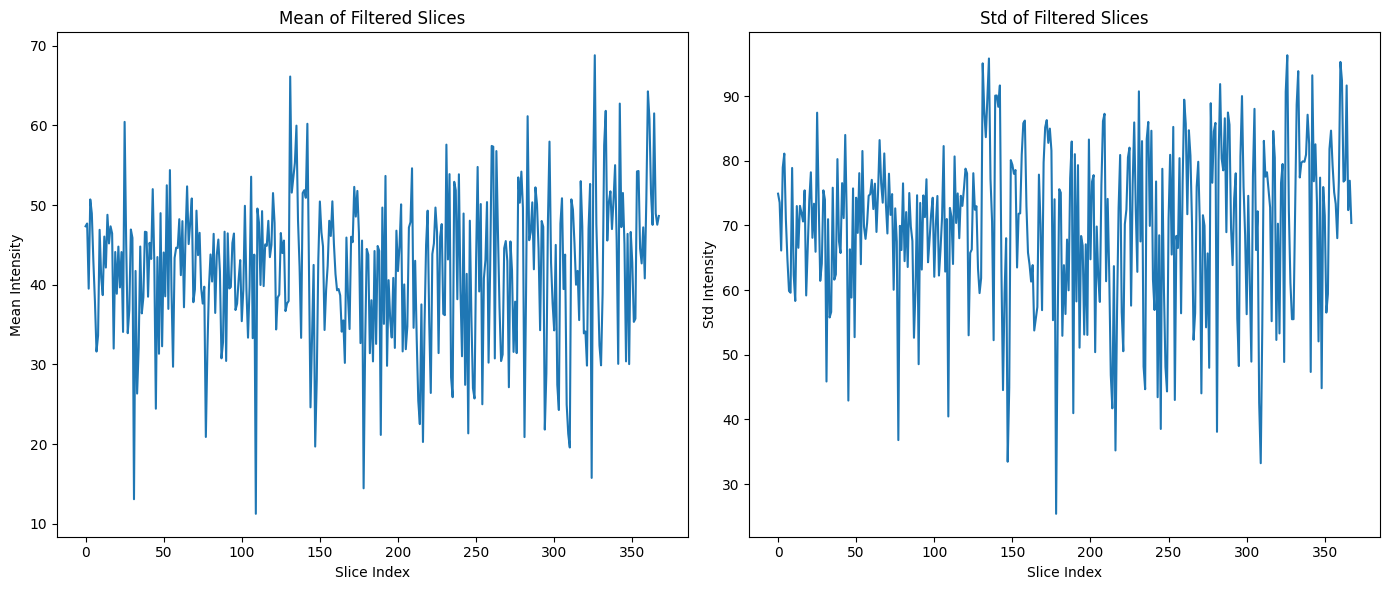

In [26]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

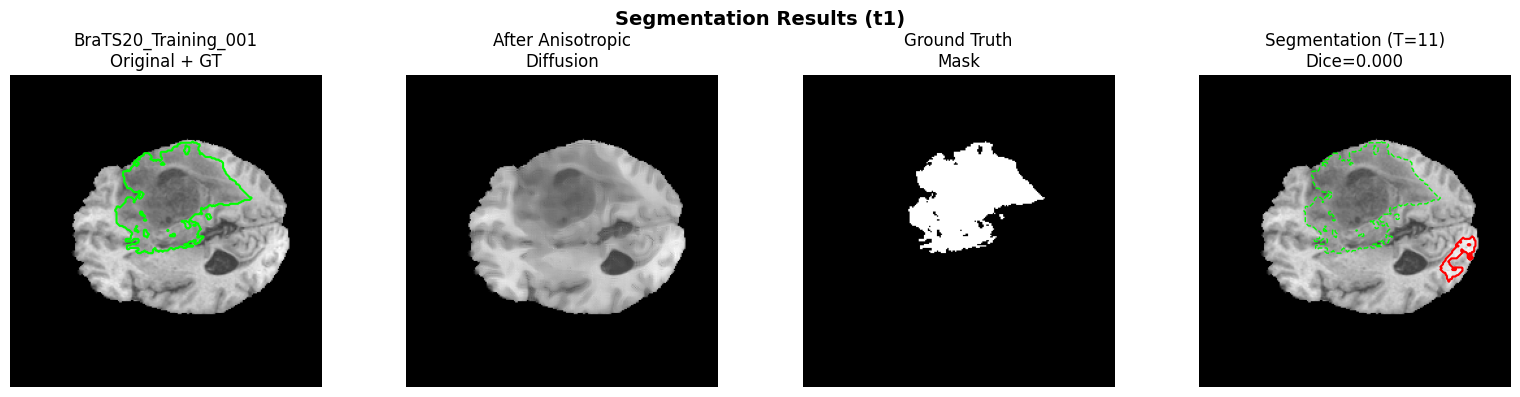

In [27]:
# visualize first sample
visualize_first_sample(segmented_cases, use_modality)

In [28]:
# evaluation
results_df2 = evaluate_segmentation_results(segmented_cases, modality=use_modality)

Evaluation Results (t1)
Samples evaluated: 368
Samples with empty mask: 0
               dice           iou         nsd
count  3.680000e+02  3.680000e+02  368.000000
mean   9.396201e-02  5.554447e-02    0.078226
std    1.389949e-01  8.616321e-02    0.111686
min    3.413668e-12  3.413668e-12    0.000000
25%    4.390856e-11  4.390856e-11    0.000000
50%    2.143662e-03  1.072990e-03    0.001969
75%    1.704470e-01  9.316341e-02    0.126961
max    5.589402e-01  3.878674e-01    0.526042


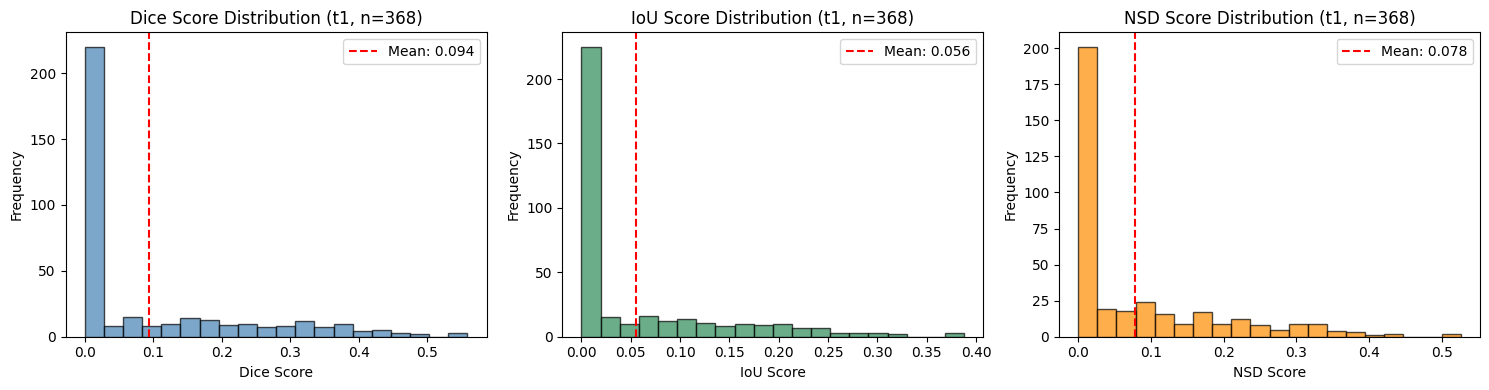

In [29]:
# distributions of evaluation metrics
plot_evaluation_histograms(results_df2, modality=use_modality)

## T1CE

In [30]:
use_modality = 't1ce'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering (t1ce): 100%|██████████| 369/369 [00:29<00:00, 12.63case/s]



Successfully filtered 368 cases with anisotropic diffusion


Segmentation: 100%|██████████| 368/368 [01:49<00:00,  3.38case/s]


Successfully segmented 368 cases


In [31]:
# mean inference time

filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, segmentation: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 264.88 ms
filter: 9.26 ms, segmentation: 255.62 ms


Training slice count: 368


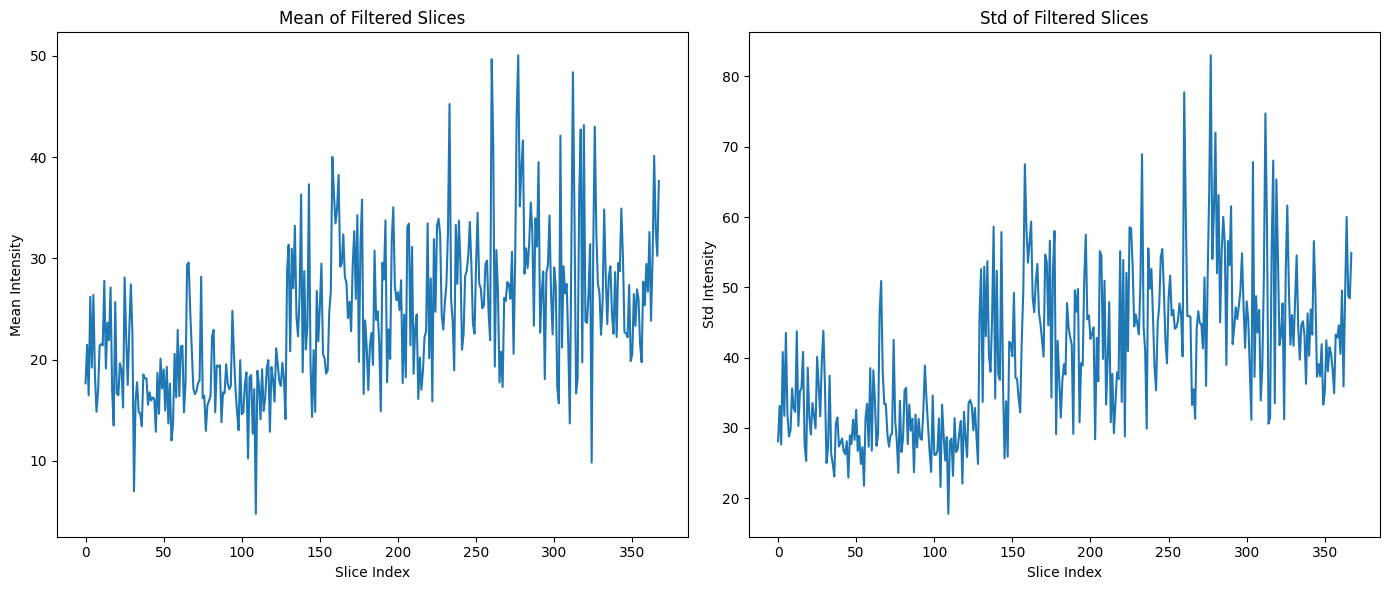

In [32]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

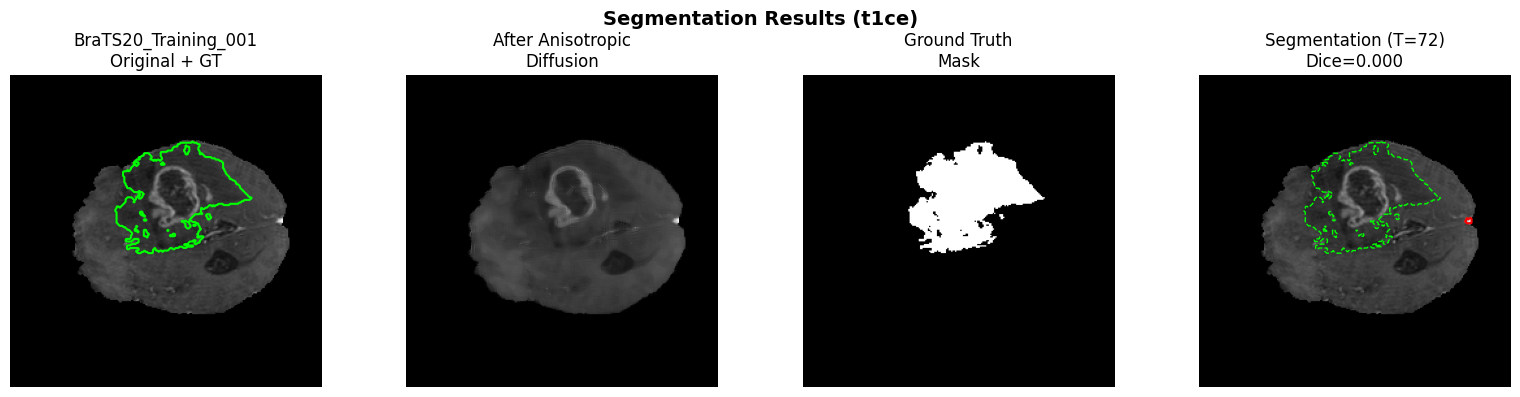

In [33]:
# visualize first sample
visualize_first_sample(segmented_cases, use_modality)

In [34]:
# evaluation
results_df2 = evaluate_segmentation_results(segmented_cases, modality=use_modality)

Evaluation Results (t1ce)
Samples evaluated: 368
Samples with empty mask: 0
               dice           iou         nsd
count  3.680000e+02  3.680000e+02  368.000000
mean   1.143558e-01  6.669167e-02    0.068950
std    1.361695e-01  8.425937e-02    0.105324
min    3.331779e-12  3.331779e-12    0.000000
25%    6.211187e-11  6.211187e-11    0.000000
50%    5.579382e-02  2.869789e-02    0.000000
75%    2.100702e-01  1.173637e-01    0.102056
max    6.110485e-01  4.399351e-01    0.558219


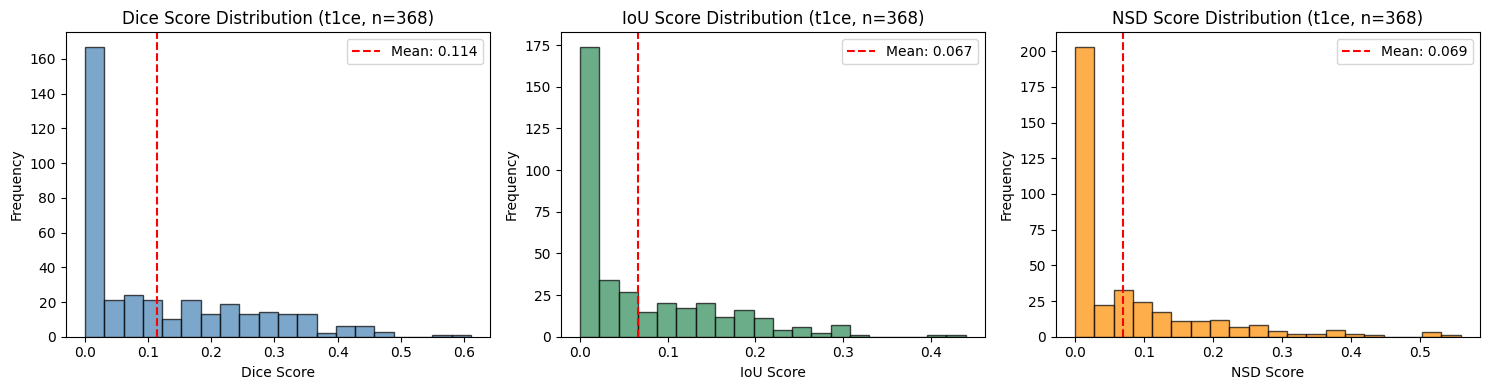

In [35]:
# distributions of evaluation metrics
plot_evaluation_histograms(results_df2, modality=use_modality)

## T2

In [36]:
use_modality = 't2'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering (t2): 100%|██████████| 369/369 [00:29<00:00, 12.32case/s]



Successfully filtered 368 cases with anisotropic diffusion


Segmentation: 100%|██████████| 368/368 [01:22<00:00,  4.48case/s]


Successfully segmented 368 cases


In [37]:
# mean inference time

filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, segmentation: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 191.43 ms
filter: 9.30 ms, segmentation: 182.14 ms


Training slice count: 368


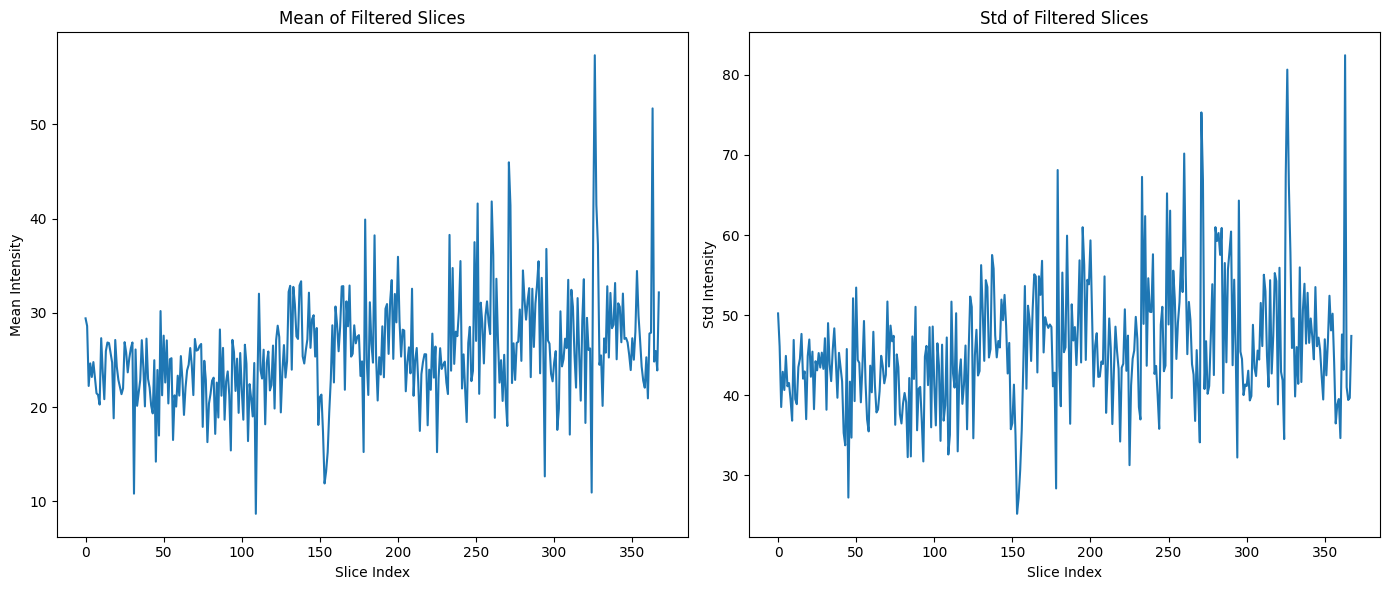

In [38]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

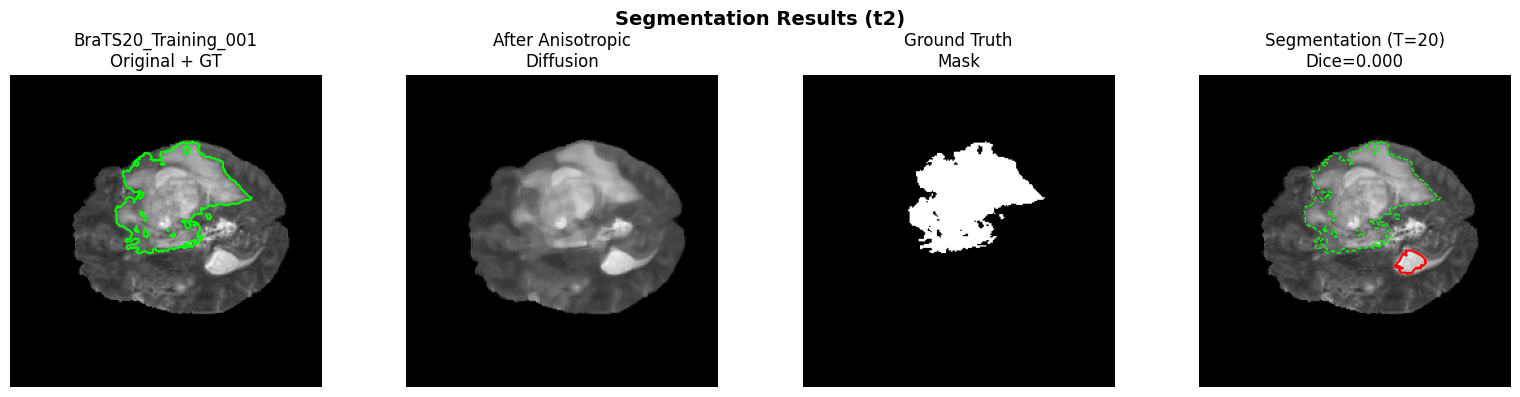

In [39]:
# visualize first sample
visualize_first_sample(segmented_cases, use_modality)

In [40]:
# evaluation
results_df2 = evaluate_segmentation_results(segmented_cases, modality=use_modality)

Evaluation Results (t2)
Samples evaluated: 368
Samples with empty mask: 0
               dice           iou         nsd
count  3.680000e+02  3.680000e+02  368.000000
mean   6.666023e-02  3.941285e-02    0.036522
std    1.219692e-01  7.906261e-02    0.086348
min    3.375072e-12  3.375072e-12    0.000000
25%    3.848009e-11  3.848009e-11    0.000000
50%    8.388207e-11  8.388207e-11    0.000000
75%    8.746385e-02  4.573223e-02    0.010883
max    7.147920e-01  5.561684e-01    0.477689


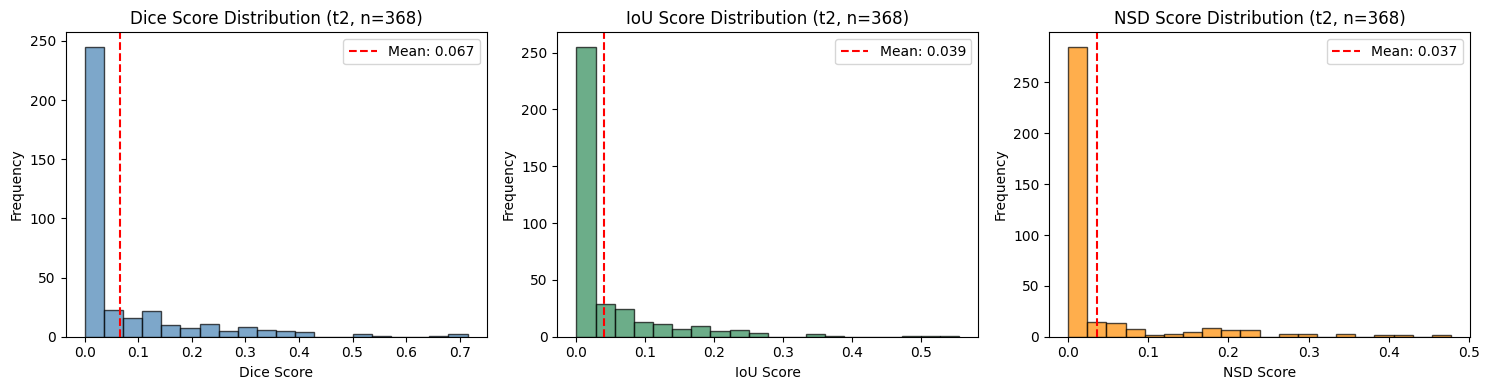

In [41]:
# distributions of evaluation metrics
plot_evaluation_histograms(results_df2, modality=use_modality)